In [3]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import json
import numpy as np
from collections import defaultdict
import h5py
import pandas as pd

In [60]:
USER = "chengshu"
ROOT_DIR = "/mnt"
PROJECT = "momagen"

TASK = "clean_pan"
DR = "D2"
# ABLATIONS = ["full"]
ABLATIONS = ["full", "no_vis"]

# ABLATIONS = ["no_vis", "only_hard", "full"]

# ABLATIONS = ["no_vis", "only_hard", "only_soft", "full"]
# ABLATIONS = ["no_vis", "only_hard"]
# ABLATIONS = ["no_vis"]
TOTAL_DEMOS = 1000

In [61]:
for ABLATION in ABLATIONS:
    FOLDER = f"{TASK}_{ABLATION}"
    if TASK == "tidy_table" and ABLATION == "full":
        PATH = f"{ROOT_DIR}/{USER}/{PROJECT}/{FOLDER}_old"
    else:
        PATH = f"{ROOT_DIR}/{USER}/{PROJECT}/{FOLDER}"
    for folder in sorted(os.listdir(PATH)):
        print(ABLATION, folder)
        folder_path = os.path.join(PATH, folder)
        for subfolder in sorted(os.listdir(folder_path)):
            if DR not in subfolder: continue
            stats_json_file = os.path.join(folder_path, subfolder, "subtask_lengths.json")
            demo_hdf5_file = os.path.join(folder_path, subfolder, "demo.hdf5")
            if os.path.isfile(stats_json_file): continue
            subtask_lengths = dict()
            if not os.path.isfile(demo_hdf5_file): continue
            print(demo_hdf5_file)
            with h5py.File(demo_hdf5_file, "r") as hdf5_f:
                for demo_key in hdf5_f["data"]:
                    subtask_lengths[demo_key] = hdf5_f["data"][demo_key]["subtask_lengths"][:].tolist()
            print("num of demos stats collected", len(subtask_lengths))
            with open(stats_json_file, "w+") as f:
                json.dump(subtask_lengths, f)

full r1_clean_pan_worker_0
/mnt/chengshu/momagen/clean_pan_full/r1_clean_pan_worker_0/demo_src_r1_clean_pan_task_D2/demo.hdf5
num of demos stats collected 5
full r1_clean_pan_worker_1
/mnt/chengshu/momagen/clean_pan_full/r1_clean_pan_worker_1/demo_src_r1_clean_pan_task_D2/demo.hdf5
num of demos stats collected 5
full r1_clean_pan_worker_2
/mnt/chengshu/momagen/clean_pan_full/r1_clean_pan_worker_2/demo_src_r1_clean_pan_task_D2/demo.hdf5
num of demos stats collected 5
full r1_clean_pan_worker_3
/mnt/chengshu/momagen/clean_pan_full/r1_clean_pan_worker_3/demo_src_r1_clean_pan_task_D2/demo.hdf5
num of demos stats collected 5
full r1_clean_pan_worker_4
/mnt/chengshu/momagen/clean_pan_full/r1_clean_pan_worker_4/demo_src_r1_clean_pan_task_D2/demo.hdf5
num of demos stats collected 5
full r1_clean_pan_worker_5
/mnt/chengshu/momagen/clean_pan_full/r1_clean_pan_worker_5/demo_src_r1_clean_pan_task_D2/demo.hdf5
num of demos stats collected 5
full r1_clean_pan_worker_6
/mnt/chengshu/momagen/clean_pan

In [62]:
num_success = defaultdict(list)
num_attempts = defaultdict(list)
visibility_perc = defaultdict(list)
episode_length = defaultdict(list)

for ABLATION in ABLATIONS:
    FOLDER = f"{TASK}_{ABLATION}"
    if PROJECT =="momagen" and TASK == "tidy_table" and ABLATION == "full":
        PATH = f"{ROOT_DIR}/{USER}/{PROJECT}/{FOLDER}_old"
    else:
        PATH = f"{ROOT_DIR}/{USER}/{PROJECT}/{FOLDER}"
    for folder in sorted(os.listdir(PATH)):
        # print(ABLATION, folder)
        folder_path = os.path.join(PATH, folder)
        for subfolder in sorted(os.listdir(folder_path)):
            if DR not in subfolder: continue
            stats_json_file = os.path.join(folder_path, subfolder, "important_stats.json")
            subtask_json_file = os.path.join(folder_path, subfolder, "subtask_lengths.json")
            if os.path.exists(stats_json_file):
                with open(stats_json_file) as f:
                    data = json.load(f)

                num_success[ABLATION].append(data["num_success"])
                num_attempts[ABLATION].append(data["num_attempts"])

                all_episode_logs = data["all_episode_logs"]
                success_episode_id = 0

                with open(subtask_json_file) as f:
                    subtask_data = json.load(f)

                for task_success, phase_logs in zip(all_episode_logs["task_success"], all_episode_logs["phase_logs"]):
                    if not task_success: continue
                    # print(len(phase_logs))
                    # this should not happen, debug!
                    if len(phase_logs) == 0: continue
                    subtask_lengths = subtask_data[f"demo_{success_episode_id}"]
                    num_visible_frames = 0
                    num_total_frames = 0
                    for phase_id, phase_log in enumerate(phase_logs.values()):
                        if phase_log["phase_type"] != "navigation": continue
                        # print(phase_id)
                        # Legacy: just head camera for navigation
                        # print(phase_log)
                        # assert False
                        if "num_frames_with_obj_visible" in phase_log:
                            num_visible_frames += phase_log["num_frames_with_obj_visible"] * subtask_lengths[phase_id]
                        elif "visibility_stats" in phase_log:
                            for key in phase_log["visibility_stats"]:
                                if "eye" in key and "nav" in key:
                                    num_visible_frames += phase_log["visibility_stats"][key] * subtask_lengths[phase_id]
                        num_total_frames += subtask_lengths[phase_id]
                    visibility_perc[ABLATION].append(num_visible_frames / num_total_frames)
                    success_episode_id += 1


In [63]:
success_rate_list = []
avg_visibility_perc_list = []

ABLATION_TEXT = {
    "full": "MoMaGen Full",
    "only_hard": "MoMaGen w/o Soft Vis. Const.",
    "only_soft": "MoMaGen w/o Hard Vis. Const.",
    "no_vis": "MoMaGen w/o Vis. Const.",
}
for ABLATION in ABLATION_TEXT:
    total_successes = np.sum(num_success[ABLATION])
    total_attempts = np.sum(num_attempts[ABLATION])
    # print(ABLATION, total_successes)
    # assert total_successes == TOTAL_DEMOS
    success_rate = total_successes / total_attempts
    print(ABLATION, "success_rate", success_rate)
    success_rate_list.append(success_rate)
    print(ABLATION, len(visibility_perc[ABLATION]))
    # assert len(visibility_perc[ABLATION]) == total_successes
    # sns.histplot(visibility_perc[ABLATION][:1000], binwidth=0.001, alpha=0.8, label=ABLATION_TEXT[ABLATION], legend=True)
    avg_visibility_perc = np.mean(visibility_perc[ABLATION][:1000])
    print(ABLATION, "avg_visibility_perc", avg_visibility_perc)
    avg_visibility_perc_list.append(avg_visibility_perc)
    # print((np.array(visibility_perc[ABLATION]) < 0.8).sum())


full success_rate 0.15772870662460567
full 50
full avg_visibility_perc 0.8083266149430157
only_hard success_rate nan
only_hard 0
only_hard avg_visibility_perc nan
only_soft success_rate nan
only_soft 0
only_soft avg_visibility_perc nan
no_vis success_rate 0.12362637362637363
no_vis 45
no_vis avg_visibility_perc 0.43816878112229074


/tmp/user/16322/ipykernel_1032419/3910912451.py:15: RuntimeWarning: invalid value encountered in scalar divide
  success_rate = total_successes / total_attempts


full success_rate 0.8635578583765112
full avg_visibility_perc 0.9989063958570055
only_hard success_rate 0.8802816901408451
only_hard avg_visibility_perc 0.9957257612377587
only_soft success_rate 0.9727626459143969
only_soft avg_visibility_perc 0.9766924128467017
no_vis success_rate 0.9671179883945842
no_vis avg_visibility_perc 0.9047774863450664


Text(0.5, 1.0, 'Pick Cup (D0)')

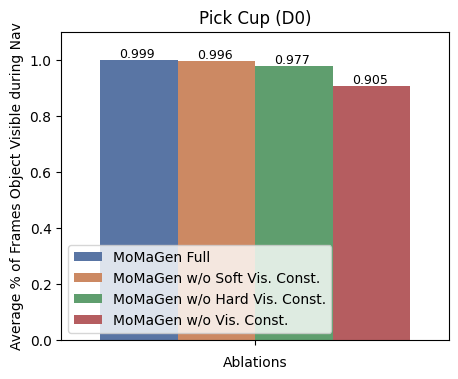

In [429]:
success_rate_list = []
avg_visibility_perc_list = []

ABLATION_TEXT = {
    "full": "MoMaGen Full",
    "only_hard": "MoMaGen w/o Soft Vis. Const.",
    "only_soft": "MoMaGen w/o Hard Vis. Const.",
    "no_vis": "MoMaGen w/o Vis. Const.",
}
for ABLATION in ABLATION_TEXT:
    total_successes = np.sum(num_success[ABLATION])
    total_attempts = np.sum(num_attempts[ABLATION])
    # print(ABLATION, total_successes)
    # assert total_successes == TOTAL_DEMOS
    success_rate = total_successes / total_attempts
    print(ABLATION, "success_rate", success_rate)
    success_rate_list.append(success_rate)
    # print(ABLATION, len(visibility_perc[ABLATION]))
    # assert len(visibility_perc[ABLATION]) == total_successes
    # sns.histplot(visibility_perc[ABLATION][:1000], binwidth=0.001, alpha=0.8, label=ABLATION_TEXT[ABLATION], legend=True)
    avg_visibility_perc = np.mean(visibility_perc[ABLATION][:1000])
    print(ABLATION, "avg_visibility_perc", avg_visibility_perc)
    avg_visibility_perc_list.append(avg_visibility_perc)
    # print((np.array(visibility_perc[ABLATION]) < 0.8).sum())

data = {
    'Method': ABLATION_TEXT.values(),
    'Average % of Frames Object Visible during Nav': avg_visibility_perc_list,
}
plt.figure(figsize=(5, 4))
sns.barplot(data=data, hue='Method', y='Average % of Frames Object Visible during Nav', palette='deep', width=0.8, legend=True)


start = [-0.35]
offset = 0.2
num_offsets = 4

x_pos_list = []
for s in start:
    for o in range(num_offsets):
        x_pos_list.append(s + o * offset)

# Add value labels
for i in range(len(x_pos_list)):
    val = avg_visibility_perc_list[i]
    xpos = x_pos_list[i]
    plt.text(xpos, val + 0.01, f'{val:.3f}', fontsize=9)

plt.xlabel("Ablations")
plt.ylim(0, 1.1)
plt.legend(loc='lower left')
plt.title("Pick Cup (D0)")


full success_rate 0.7990411506192568
full avg_visibility_perc 0.8613708144328677
only_hard success_rate 0.78125
only_hard avg_visibility_perc 0.6346663862047092
only_soft success_rate 0.5927682276229994
only_soft avg_visibility_perc 0.6268243043420438
no_vis success_rate 0.7380073800738007
no_vis avg_visibility_perc 0.4644067022246019


Text(0.5, 1.0, 'Tidy Table (D0)')

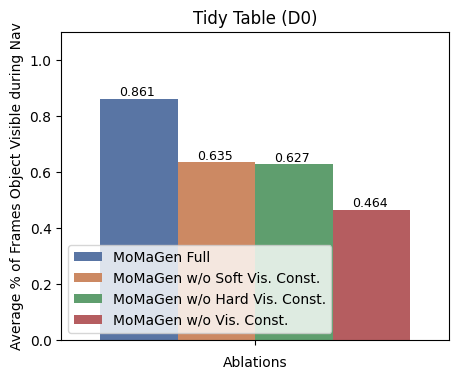

In [425]:
success_rate_list = []
avg_visibility_perc_list = []

ABLATION_TEXT = {
    "full": "MoMaGen Full",
    "only_hard": "MoMaGen w/o Soft Vis. Const.",
    "only_soft": "MoMaGen w/o Hard Vis. Const.",
    "no_vis": "MoMaGen w/o Vis. Const.",
}
for ABLATION in ABLATION_TEXT:
    total_successes = np.sum(num_success[ABLATION])
    total_attempts = np.sum(num_attempts[ABLATION])
    # print(ABLATION, total_successes)
    # assert total_successes == TOTAL_DEMOS
    success_rate = total_successes / total_attempts
    print(ABLATION, "success_rate", success_rate)
    success_rate_list.append(success_rate)
    # print(ABLATION, len(visibility_perc[ABLATION]))
    # assert len(visibility_perc[ABLATION]) == total_successes
    # sns.histplot(visibility_perc[ABLATION][:1000], binwidth=0.001, alpha=0.8, label=ABLATION_TEXT[ABLATION], legend=True)
    avg_visibility_perc = np.mean(visibility_perc[ABLATION][:1000])
    print(ABLATION, "avg_visibility_perc", avg_visibility_perc)
    avg_visibility_perc_list.append(avg_visibility_perc)
    # print((np.array(visibility_perc[ABLATION]) < 0.8).sum())

data = {
    'Method': ABLATION_TEXT.values(),
    'Average % of Frames Object Visible during Nav': avg_visibility_perc_list,
}
plt.figure(figsize=(5, 4))
sns.barplot(data=data, hue='Method', y='Average % of Frames Object Visible during Nav', palette='deep', width=0.8, legend=True)


start = [-0.35]
offset = 0.2
num_offsets = 4

x_pos_list = []
for s in start:
    for o in range(num_offsets):
        x_pos_list.append(s + o * offset)

# Add value labels
for i in range(len(x_pos_list)):
    val = avg_visibility_perc_list[i]
    xpos = x_pos_list[i]
    plt.text(xpos, val + 0.01, f'{val:.3f}', fontsize=9)

plt.xlabel("Ablations")
plt.ylim(0, 1.1)
plt.legend(loc='lower left')
plt.title("Tidy Table (D0)")

full success_rate 0.7990411506192568
full avg_visibility_perc 0.8613708144328677
only_hard success_rate 0.78125
only_hard avg_visibility_perc 0.6346663862047092
only_soft success_rate 0.5927682276229994
only_soft avg_visibility_perc 0.6268243043420438
no_vis success_rate 0.7380073800738007
no_vis avg_visibility_perc 0.4644067022246019


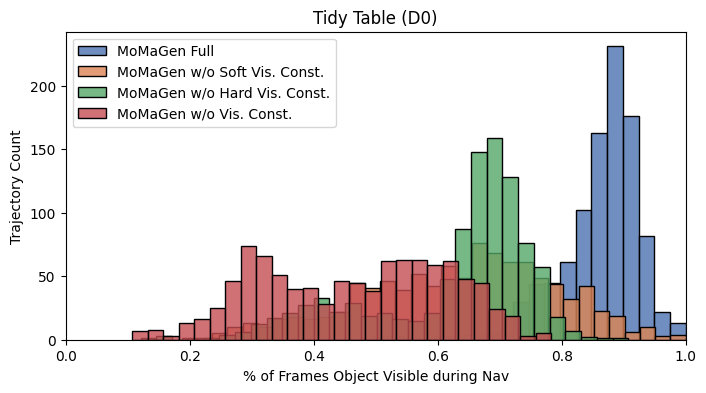

In [405]:
success_rate_list = []
avg_visibility_perc_list = []

ABLATION_TEXT = {
    "full": "MoMaGen Full",
    "only_hard": "MoMaGen w/o Soft Vis. Const.",
    "only_soft": "MoMaGen w/o Hard Vis. Const.",
    "no_vis": "MoMaGen w/o Vis. Const.",
}
plt.figure(figsize=(8, 4))

palette = sns.color_palette("deep")
for i, ABLATION in enumerate(ABLATION_TEXT):
    total_successes = np.sum(num_success[ABLATION])
    total_attempts = np.sum(num_attempts[ABLATION])
    # print(ABLATION, total_successes)
    # assert total_successes == TOTAL_DEMOS
    success_rate = total_successes / total_attempts
    print(ABLATION, "success_rate", success_rate)
    success_rate_list.append(success_rate)
    # print(ABLATION, len(visibility_perc[ABLATION]))
    # assert len(visibility_perc[ABLATION]) == total_successes
    sns.histplot(x=visibility_perc[ABLATION][:1000], binwidth=0.025, alpha=0.8, label=ABLATION_TEXT[ABLATION], color=palette[i], legend=True)
    avg_visibility_perc = np.mean(visibility_perc[ABLATION][:1000])
    print(ABLATION, "avg_visibility_perc", avg_visibility_perc)
    avg_visibility_perc_list.append(avg_visibility_perc)
    # print((np.array(visibility_perc[ABLATION]) < 0.8).sum())

plt.xlim(0, 1)
plt.xlabel("% of Frames Object Visible during Nav")
plt.ylabel("Trajectory Count")
plt.title("Tidy Table (D0)")
plt.legend()

[0.7990411506192568, 0.78125, 0.5927682276229994, 0.7380073800738007]


<Axes: xlabel='methods', ylabel='success_rate'>

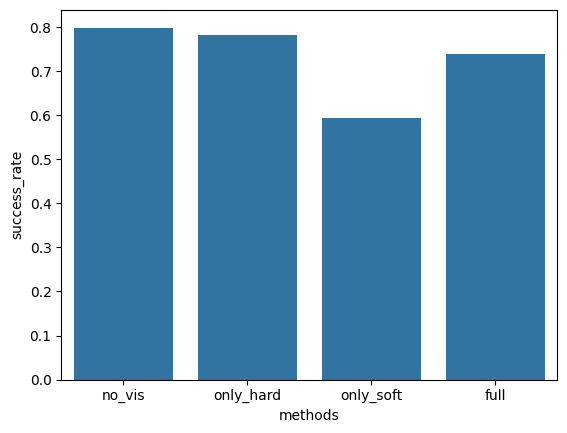

In [458]:
data = {
    "methods": ABLATIONS,
    "success_rate": success_rate_list,
}

print(success_rate_list)

sns.barplot(x="methods", y="success_rate", data=data)

<Axes: xlabel='methods', ylabel='avg_visibility_perc'>

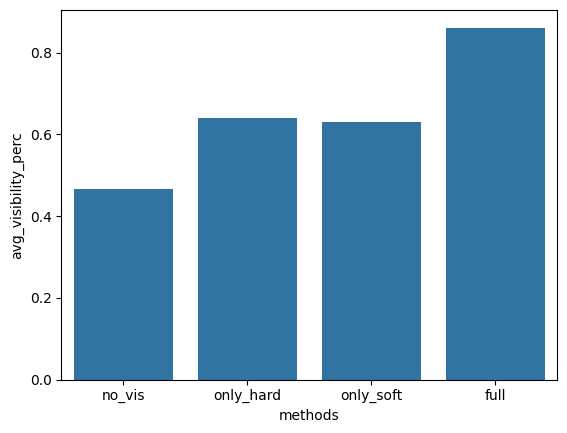

In [151]:
data = {
    "methods": ABLATIONS,
    "avg_visibility_perc": avg_visibility_perc_list,
}

sns.barplot(x="methods", y="avg_visibility_perc", data=data)

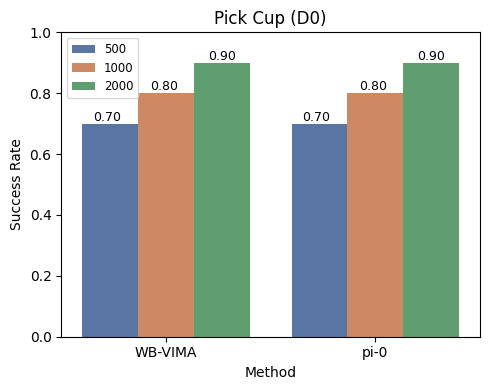

In [401]:
# Data setup
data = {
    'Method': ['WB-VIMA', 'WB-VIMA', 'WB-VIMA', 'pi-0', 'pi-0', 'pi-0'],
    'Sample Size': ['500', '1000', '2000', '500', '1000', '2000'],
    'Success Rate': [0.7, 0.8, 0.9, 0.7, 0.8, 0.9]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(5, 4))
sns.barplot(data=df, x='Method', y='Success Rate', hue='Sample Size', palette='deep', width=0.8)

x_pos_list = [-0.35, -0.075, 0.2, 0.65, 0.925, 1.2]
# Add value labels
for i in range(len(df)):
    method = df.iloc[i]['Method']
    sample = df.iloc[i]['Sample Size']
    val = df.iloc[i]['Success Rate']
    xpos = x_pos_list[i]
    plt.text(xpos, val + 0.01, f'{val:.2f}', fontsize=9)

# Aesthetics
plt.title("Pick Cup (D0)")
plt.ylim(0, 1)
plt.tight_layout()
plt.legend(title=None, fontsize="small")
plt.show()

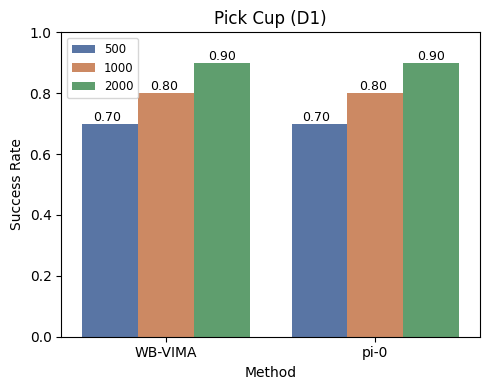

In [225]:
# Data setup
data = {
    'Method': ['WB-VIMA', 'WB-VIMA', 'WB-VIMA', 'pi-0', 'pi-0', 'pi-0'],
    'Sample Size': ['500', '1000', '2000', '500', '1000', '2000'],
    'Success Rate': [0.7, 0.8, 0.9, 0.7, 0.8, 0.9]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(5, 4))
sns.barplot(data=df, x='Method', y='Success Rate', hue='Sample Size', palette='deep', width=0.8)

x_pos_list = [-0.35, -0.075, 0.2, 0.65, 0.925, 1.2]
# Add value labels
for i in range(len(df)):
    method = df.iloc[i]['Method']
    sample = df.iloc[i]['Sample Size']
    val = df.iloc[i]['Success Rate']
    xpos = x_pos_list[i]
    plt.text(xpos, val + 0.01, f'{val:.2f}', fontsize=9)

# Aesthetics
plt.title("Pick Cup (D1)")
plt.ylim(0, 1)
plt.tight_layout()
plt.legend(title=None, fontsize="small")
plt.show()

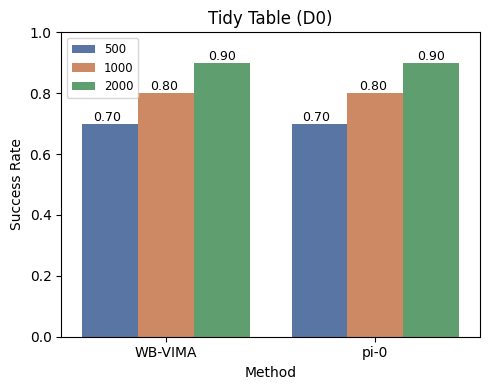

In [230]:
# Data setup
data = {
    'Method': ['WB-VIMA', 'WB-VIMA', 'WB-VIMA', 'pi-0', 'pi-0', 'pi-0'],
    'Sample Size': ['500', '1000', '2000', '500', '1000', '2000'],
    'Success Rate': [0.7, 0.8, 0.9, 0.7, 0.8, 0.9]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(5, 4))
sns.barplot(data=df, x='Method', y='Success Rate', hue='Sample Size', palette='deep', width=0.8)

x_pos_list = [-0.35, -0.075, 0.2, 0.65, 0.925, 1.2]
# Add value labels
for i in range(len(df)):
    method = df.iloc[i]['Method']
    sample = df.iloc[i]['Sample Size']
    val = df.iloc[i]['Success Rate']
    xpos = x_pos_list[i]
    plt.text(xpos, val + 0.01, f'{val:.2f}', fontsize=9)

# Aesthetics
plt.title("Tidy Table (D0)")
plt.ylim(0, 1)
plt.tight_layout()
plt.legend(title=None, fontsize="small")
plt.show()

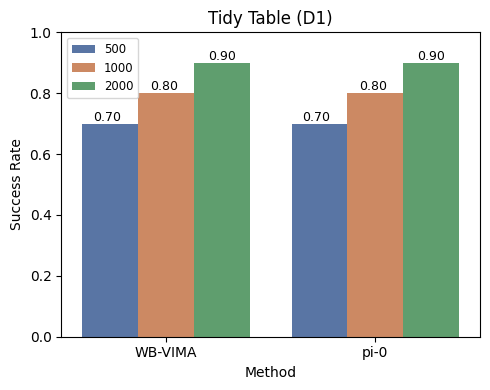

In [231]:
# Data setup
data = {
    'Method': ['WB-VIMA', 'WB-VIMA', 'WB-VIMA', 'pi-0', 'pi-0', 'pi-0'],
    'Sample Size': ['500', '1000', '2000', '500', '1000', '2000'],
    'Success Rate': [0.7, 0.8, 0.9, 0.7, 0.8, 0.9]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(5, 4))
sns.barplot(data=df, x='Method', y='Success Rate', hue='Sample Size', palette='deep', width=0.8)

x_pos_list = [-0.35, -0.075, 0.2, 0.65, 0.925, 1.2]
# Add value labels
for i in range(len(df)):
    method = df.iloc[i]['Method']
    sample = df.iloc[i]['Sample Size']
    val = df.iloc[i]['Success Rate']
    xpos = x_pos_list[i]
    plt.text(xpos, val + 0.01, f'{val:.2f}', fontsize=9)

# Aesthetics
plt.title("Tidy Table (D1)")
plt.ylim(0, 1)
plt.tight_layout()
plt.legend(title=None, fontsize="small")
plt.show()

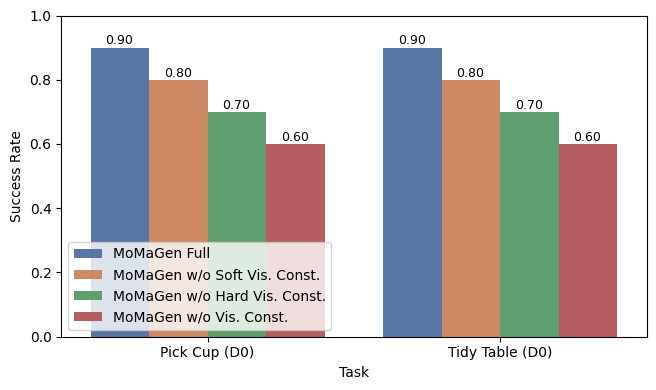

In [273]:
# Data setup
data = {
    'Task': ['Pick Cup (D0)', 'Pick Cup (D0)', 'Pick Cup (D0)', 'Pick Cup (D0)', 'Tidy Table (D0)', 'Tidy Table (D0)', 'Tidy Table (D0)', 'Tidy Table (D0)'],
    'Ablation': ['MoMaGen Full', 'MoMaGen w/o Soft Vis. Const.', 'MoMaGen w/o Hard Vis. Const.', 'MoMaGen w/o Vis. Const.', 'MoMaGen Full', 'MoMaGen w/o Soft Vis. Const.', 'MoMaGen w/o Hard Vis. Const.', 'MoMaGen w/o Vis. Const.'],
    'Success Rate': [0.9, 0.8, 0.7, 0.6, 0.9, 0.8, 0.7, 0.6]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(6.6666, 4))
sns.barplot(data=df, x='Task', y='Success Rate', hue='Ablation', palette='deep', width=0.8)

start = [-0.35, 0.65]
offset = 0.2
num_offsets = 4

x_pos_list = []
for s in start:
    for o in range(num_offsets):
        x_pos_list.append(s + o * offset)

# Add value labels
for i in range(len(df)):
    val = df.iloc[i]['Success Rate']
    xpos = x_pos_list[i]
    plt.text(xpos, val + 0.01, f'{val:.2f}', fontsize=9)

# Aesthetics
# plt.title("Compare with Ablations")
plt.ylim(0, 1)
plt.tight_layout()
plt.legend(title=None)

plt.show()

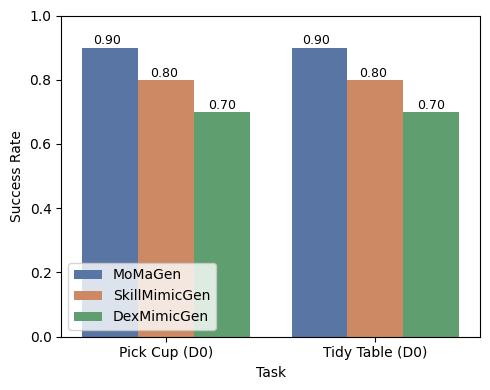

In [274]:
# Data setup
data = {
    'Task': ['Pick Cup (D0)', 'Pick Cup (D0)', 'Pick Cup (D0)', 'Tidy Table (D0)', 'Tidy Table (D0)', 'Tidy Table (D0)'],
    'Method': ['MoMaGen', 'SkillMimicGen', 'DexMimicGen', 'MoMaGen', 'SkillMimicGen', 'DexMimicGen'],
    'Success Rate': [0.9, 0.8, 0.7, 0.9, 0.8, 0.7]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(5, 4))
sns.barplot(data=df, x='Task', y='Success Rate', hue='Method', palette='deep', width=0.8)

x_pos_list = [-0.35, -0.075, 0.2, 0.65, 0.925, 1.2]
# Add value labels
for i in range(len(df)):
    val = df.iloc[i]['Success Rate']
    xpos = x_pos_list[i]
    plt.text(xpos, val + 0.01, f'{val:.2f}', fontsize=9)

# Aesthetics
# plt.title("Compare with Baselines")
plt.ylim(0, 1)
plt.tight_layout()
plt.legend(title=None, loc='lower left')
plt.show()

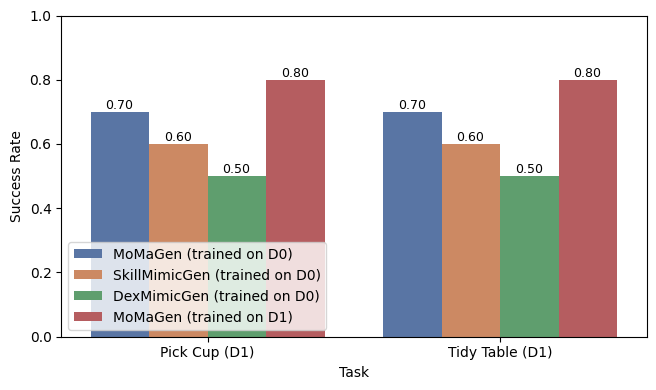

In [296]:
# Data setup
data = {
    'Task': ['Pick Cup (D1)', 'Pick Cup (D1)', 'Pick Cup (D1)', 'Pick Cup (D1)', 'Tidy Table (D1)', 'Tidy Table (D1)', 'Tidy Table (D1)', 'Tidy Table (D1)'],
    'Method': ['MoMaGen (trained on D0)', 'SkillMimicGen (trained on D0)', 'DexMimicGen (trained on D0)', 'MoMaGen (trained on D1)',
               'MoMaGen (trained on D0)', 'SkillMimicGen (trained on D0)', 'DexMimicGen (trained on D0)', 'MoMaGen (trained on D1)'],
    'Success Rate': [0.7, 0.6, 0.5, 0.8, 0.7, 0.6, 0.5, 0.8]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(6.6666666, 4))
sns.barplot(data=df, x='Task', y='Success Rate', hue='Method', palette='deep', width=0.8)

start = [-0.35, 0.65]
offset = 0.2
num_offsets = 4

x_pos_list = []
for s in start:
    for o in range(num_offsets):
        x_pos_list.append(s + o * offset)
        
# Add value labels
for i in range(len(df)):
    val = df.iloc[i]['Success Rate']
    xpos = x_pos_list[i]
    plt.text(xpos, val + 0.01, f'{val:.2f}', fontsize=9)

# Aesthetics
# plt.title("Compare with Baselines")
plt.ylim(0, 1)
plt.tight_layout()
plt.legend(title=None, loc='lower left')
plt.show()